In [1]:
from Clustering_Functions import *
import glob

In [22]:
# The Pentland Hills election that's studied in the paper
filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_names, ward = csv_parse(filename)
parties = party_abrevs(cand_names)

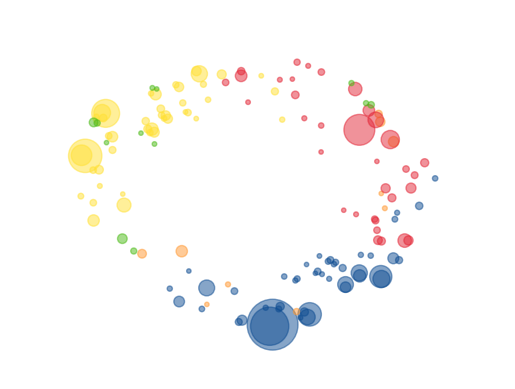

In [8]:
Ballot_MDS_plot(election, party_names=parties, threshold=10, filename='PH_threshold10.png', dpi=100)

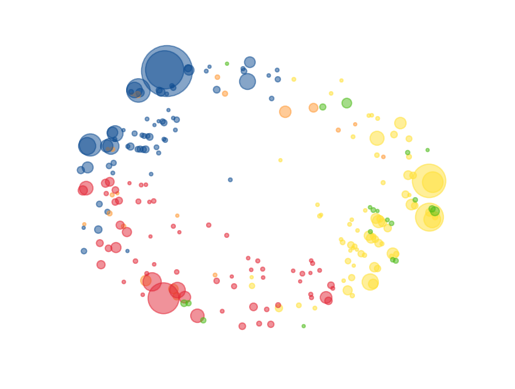

In [7]:
Ballot_MDS_plot(election, party_names=parties, threshold=5, filename='PH_threshold5.png', dpi=100)

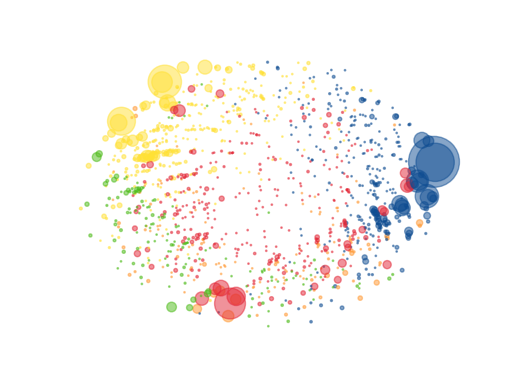

In [9]:
Ballot_MDS_plot(election, party_names=parties, threshold=1, filename='PH_threshold1.png', dpi=100)

In [32]:
C = Slate_cluster(election, verbose=True, half_penalty=False)

Slate = (3, 5).
Portion of ballots that tied = 0.008042421564295183
Portion of ballots that are consistent = 0.8297834732655767


In [33]:
C = Slate_cluster(election, verbose=True, half_penalty=True)

Slate = (1, 6).
Portion of ballots that tied = 0.005567830313742819
Portion of ballots that are consistent = 0.4269553689792311


In [34]:
C = Slate_cluster(election, slate = (1,6), verbose=True, half_penalty=False)

Portion of ballots that tied = 0.005567830313742819
Portion of ballots that are consistent = 0.8154661953159523


In [ ]:
# seven candidate elections
file_names = glob.glob(f"scot-elex/7_cands/**.csv")
for file in file_names:
    num_cands, election, cand_names, location = csv_parse(file)
    party_list = party_abrevs(cand_names)
    C = Slate_cluster(election, half_penalty=True)

In [31]:
def Slate_cluster(election, slate = None, verbose = False, half_penalty = True, 
                  share_ties = True, return_slates = False):
    """
    Returns a clustering with k=2 clusters using a slate-based method based the distance that ballots are from being strongly consistent.
    
    For each slate S={A,B} (each bi-partition of the candidates), the slate's score is computed as the sum (over the weighted ballots in the election) of the ballot's distance to the closest condition: $A>B$ or $B>A$.
    
    Note that a ballot has zero distance iff it is strongly consistent.  The slate with the minimal score is used to partition the ballots into 2 clusters.

    Args:
        election : dictionary matching ballots to weights.
        slate: (optional - to cluster based on a prescribed slate) a tuple of candidates in the first slate.
        verbose : boolean. 
        half_penalty : (boolean) whether to penalize a ballot for saying an A-candidate ties with a B-candidate 
        share_ties  : (boolean) whether to divide between the clusters the weight of a ballot that's equidistance A>B and B>A (otherwise, tied ballots are assigned to cluster B)
        return_slates : (boolean) whether to also return the slates
        
    Returns:
        A clustering (list of elections).
        (or if return_slates == True) slate_dictionary, a clustering
    """
    num_cands = max([item for ranking in election.keys() for item in ranking])
    # create a matrix X whose rows are the Borda proxies of the unique ballots
    # and a dictionary matching each ballot type with its corresponding row in the matrix
    X = []
    ballot_to_row = dict()
    counter = 0
    for ballot, weight in election.items():
        ballot_to_row[ballot]=counter
        X.append(Borda_vector(ballot,num_cands=num_cands))
        counter +=1
    
    if slate:
        best_subset = slate
    else:
        best_score = float('inf')
        best_subset = tuple()
        
        # Determine the best slate
        for A in powerset(range(1,num_cands+1)):
            B = tuple(set(range(1,num_cands+1))-set(A)) # the compliment of A
            slate_score = 0
            
            for ballot, weight in election.items(): # compute dist from the ballot to the slate
                ballot_proxy = X[ballot_to_row[ballot]]
                ballot_dist_to_A_over_B = 0
                ballot_dist_to_B_over_A = 0
                for i in A:
                    for j in B:
                        if ballot_proxy[i-1]>ballot_proxy[j-1]:
                            ballot_dist_to_B_over_A += 1
                        elif ballot_proxy[i-1]<ballot_proxy[j-1]:
                            ballot_dist_to_A_over_B += 1
                        elif half_penalty:
                            ballot_dist_to_A_over_B += 0.5
                            ballot_dist_to_B_over_A += 0.5
                dist = min(ballot_dist_to_A_over_B,ballot_dist_to_B_over_A)
                slate_score += dist*weight/(len(A)*len(B))

            if slate_score<best_score:
                best_score = slate_score
                best_subset = A
        if verbose:
            print(f"Slate = {best_subset}.")

    # Form clusters from the best slate
    A = best_subset
    B = tuple(set(range(1,num_cands+1))-set(A)) # the compliment of A
    CA = dict()
    CB = dict()
    total_shared_weight = 0
    total_consistent_ballots = 0
    
    for ballot, weight in election.items():
        ballot_proxy = X[ballot_to_row[ballot]]
        ballot_dist_to_A_over_B = 0
        ballot_dist_to_B_over_A = 0
        for i in A:
            for j in B:
                if ballot_proxy[i-1]>ballot_proxy[j-1]:
                    ballot_dist_to_B_over_A += 1
                elif ballot_proxy[i-1]<ballot_proxy[j-1]:
                    ballot_dist_to_A_over_B += 1
                elif half_penalty:
                    ballot_dist_to_A_over_B += 0.5
                    ballot_dist_to_B_over_A += 0.5
        total_consistent_ballots += weight*(ballot_dist_to_A_over_B==0 or ballot_dist_to_B_over_A==0)

        if share_ties and ballot_dist_to_A_over_B == ballot_dist_to_B_over_A:
            CA[ballot]=weight/2
            CB[ballot]=weight/2
            total_shared_weight +=weight
        elif ballot_dist_to_A_over_B < ballot_dist_to_B_over_A:
            CA[ballot]=weight
        else:
            CB[ballot]=weight
    if verbose:
        print(f"Portion of ballots that tied = {total_shared_weight/sum(election.values())}")
        print(f"Portion of ballots that are consistent = {total_consistent_ballots/sum(election.values())}")
    
    if return_slates:
        slate_dict = {0:A, 1:B}
        return slate_dict, (CA,CB)
    else:
        return CA,CB